In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../results/records.csv', index_col=0)
df['group'] = df.index.str.split('/').str[0]
df['short'] = df.index.str.split('/').str[1]

# Color palette per gruppo
groups = df['group'].unique()
cmap = plt.cm.get_cmap('tab20', len(groups))
GROUP_COLORS = {g: cmap(i) for i, g in enumerate(groups)}

print(f'{len(df)} dataset, {len(groups)} gruppi')
df.head()

57 dataset, 12 gruppi


/tmp/ipykernel_280424/1589911731.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(groups))


,ridge_k4_NTv3_650M_pre_R2,ridge_k4_NTv3_650M_pre_MSE,kmer_k4_MCC,kmer_k4_AUROC,kmer_k4_F1,kmer_k4_Accuracy,fm_NTv3_650M_pre_MCC,fm_NTv3_650M_pre_AUROC,fm_NTv3_650M_pre_F1,fm_NTv3_650M_pre_Accuracy,...,ridge_k5_hyenadna-medium-160k-seqlen-hf_R2,ridge_k5_hyenadna-medium-160k-seqlen-hf_MSE,ridge_k6_hyenadna-medium-160k-seqlen-hf_R2,ridge_k6_hyenadna-medium-160k-seqlen-hf_MSE,ridge_k7_hyenadna-medium-160k-seqlen-hf_R2,ridge_k7_hyenadna-medium-160k-seqlen-hf_MSE,ridge_k8_hyenadna-medium-160k-seqlen-hf_R2,ridge_k8_hyenadna-medium-160k-seqlen-hf_MSE,group,short
dataset,,,,,,,,,,,,,,,,,,,,,
EMP/Yeast_H3,0.369719,99.786591,0.650239,0.911121,0.824850,0.825167,0.754890,0.944402,0.877442,0.877506,...,0.652485,0.001565,0.651865,0.001580,0.615699,0.001785,0.522666,0.002312,EMP,Yeast_H3
EMP/Yeast_H3K14ac,NaN,NaN,0.363347,0.759212,0.661957,0.691276,0.513174,0.827154,0.756558,0.760666,...,0.635430,0.001530,0.645228,0.001493,0.633151,0.001558,NaN,NaN,EMP,Yeast_H3K14ac
EMP/Yeast_H3K36me3,NaN,NaN,0.417811,0.783322,0.705978,0.712279,0.552022,0.849253,0.774469,0.778118,...,0.640623,0.001526,0.649771,0.001494,NaN,NaN,NaN,NaN,EMP,Yeast_H3K36me3
EMP/Yeast_H3K4me1,NaN,NaN,0.329935,0.727753,0.655314,0.670034,0.457903,0.789825,0.727913,0.732323,...,0.635904,0.001574,0.645174,0.001540,NaN,NaN,NaN,NaN,EMP,Yeast_H3K4me1
EMP/Yeast_H3K4me2,NaN,NaN,0.282410,0.713758,0.609195,0.666051,0.327740,0.736937,0.648741,0.685062,...,0.640500,0.001509,0.648088,0.001483,NaN,NaN,NaN,NaN,EMP,Yeast_H3K4me2


## 1. Completezza dati: cosa manca?

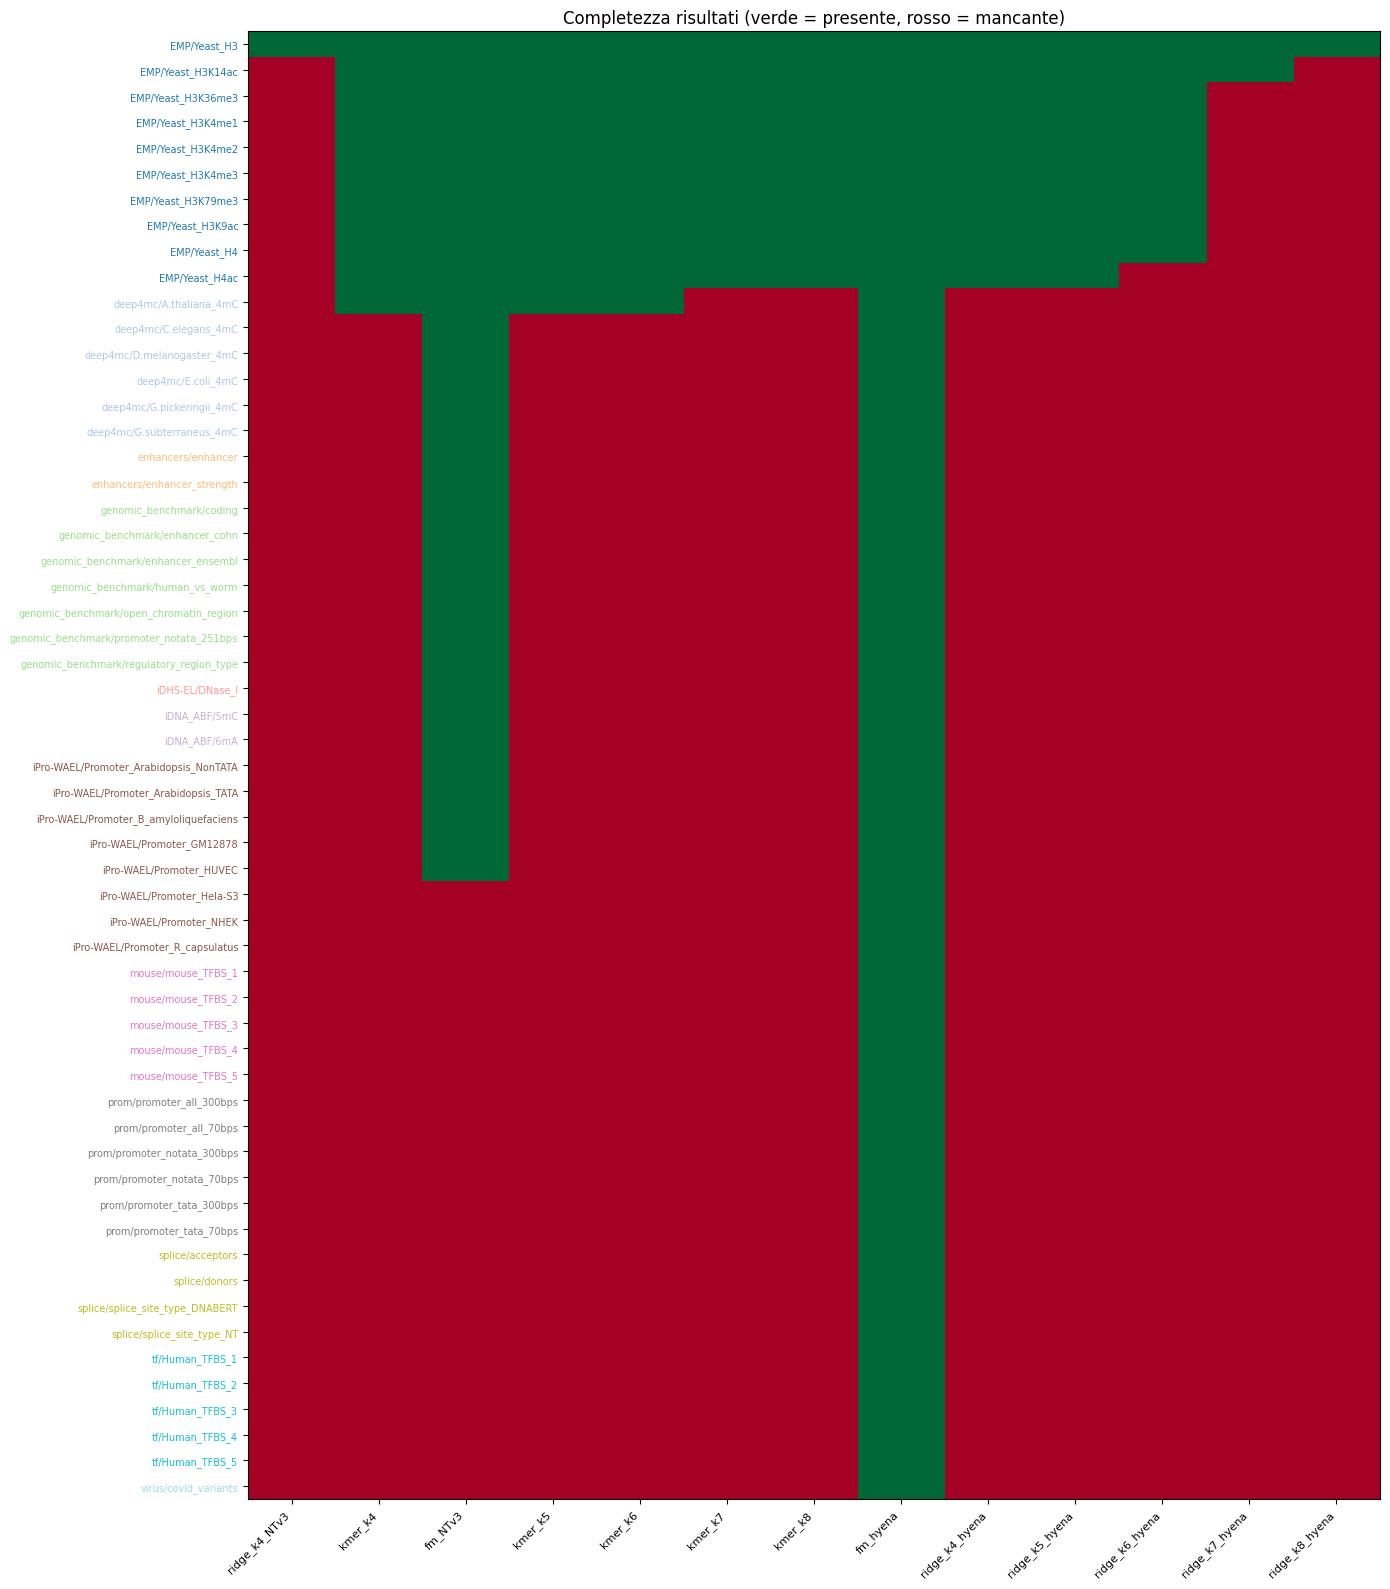

In [2]:
# Heatmap di completezza: ogni cella = se il valore esiste
metric_cols = [c for c in df.columns if c not in ('group', 'short')]

# Raggruppa colonne per tipo
col_labels = []
for c in metric_cols:
    if c.startswith('kmer_'):
        col_labels.append(c.replace('_MCC','').replace('_AUROC','').replace('_F1','').replace('_Accuracy',''))
    elif c.startswith('fm_'):
        col_labels.append(c.split('_')[1][:8])  # model short name
    elif c.startswith('ridge_'):
        parts = c.split('_')
        col_labels.append(f'ridge_{parts[1]}_{parts[2][:5]}')
    else:
        col_labels.append(c)

# Deduplica: tieni solo una colonna per (metodo, metrica_tipo)
# Usa solo _MCC o _R2 come proxy di completezza
proxy_cols = [c for c in metric_cols if c.endswith('_MCC') or c.endswith('_R2')]
proxy_labels = []
for c in proxy_cols:
    c_clean = c.replace('_MCC', '').replace('_R2', '')
    c_clean = c_clean.replace('hyenadna-medium-160k-seqlen-hf', 'hyena')
    c_clean = c_clean.replace('NTv3_650M_pre', 'NTv3')
    proxy_labels.append(c_clean)

presence = df[proxy_cols].notna().astype(int)

fig, ax = plt.subplots(figsize=(14, 16))
im = ax.imshow(presence.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(proxy_labels)))
ax.set_xticklabels(proxy_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df.index, fontsize=7)

# Colora y-labels per gruppo
for i, (_, row) in enumerate(df.iterrows()):
    ax.get_yticklabels()[i].set_color(GROUP_COLORS[row['group']])

ax.set_title('Completezza risultati (verde = presente, rosso = mancante)', fontsize=12)
plt.tight_layout()
plt.show()

## 2. HyenaDNA vs NTv3: confronto diretto (classificazione RF)

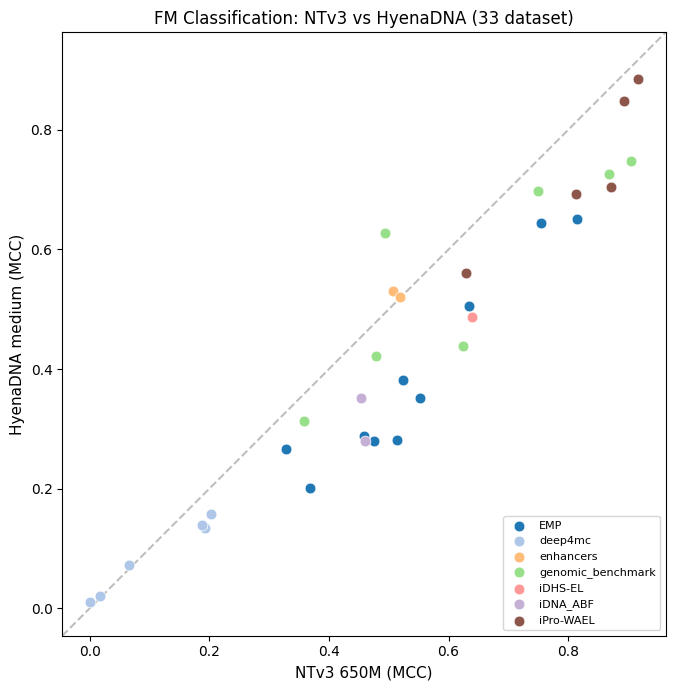

NTv3 vince: 27/33, HyenaDNA vince: 6/33


In [3]:
# Scatter: NTv3 MCC vs HyenaDNA MCC (solo dataset con entrambi)
col_nt = 'fm_NTv3_650M_pre_MCC'
col_hy = 'fm_hyenadna-medium-160k-seqlen-hf_MCC'

both = df[[col_nt, col_hy, 'group', 'short']].dropna()

fig, ax = plt.subplots(figsize=(7, 7))

for g in both['group'].unique():
    mask = both['group'] == g
    ax.scatter(both.loc[mask, col_nt], both.loc[mask, col_hy],
               c=[GROUP_COLORS[g]], label=g, s=60, edgecolors='white', linewidth=0.5, zorder=3)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='gray', alpha=0.5, zorder=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('NTv3 650M (MCC)', fontsize=11)
ax.set_ylabel('HyenaDNA medium (MCC)', fontsize=11)
ax.set_title(f'FM Classification: NTv3 vs HyenaDNA ({len(both)} dataset)', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

wins_nt = (both[col_nt] > both[col_hy]).sum()
wins_hy = (both[col_hy] > both[col_nt]).sum()
print(f'NTv3 vince: {wins_nt}/{len(both)}, HyenaDNA vince: {wins_hy}/{len(both)}')

## 3. Effetto di k sui k-mer (RF classification)

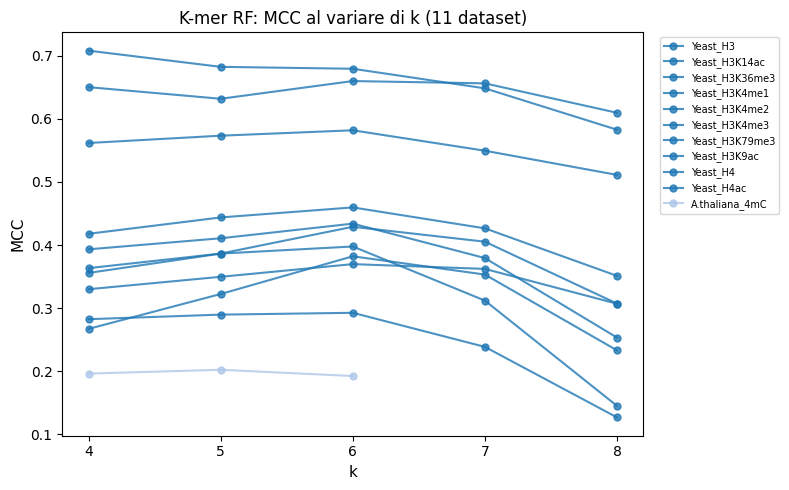

In [4]:
# Per ogni dataset (con dati k-mer), traccia MCC al variare di k
k_values = [4, 5, 6, 7, 8]
kmer_mcc_cols = [f'kmer_k{k}_MCC' for k in k_values]

kmer_data = df[kmer_mcc_cols + ['group', 'short']].dropna(subset=kmer_mcc_cols[:3])  # almeno k4-6

fig, ax = plt.subplots(figsize=(8, 5))
for idx, row in kmer_data.iterrows():
    vals = [row[c] for c in kmer_mcc_cols]
    valid_k = [k for k, v in zip(k_values, vals) if pd.notna(v)]
    valid_v = [v for v in vals if pd.notna(v)]
    ax.plot(valid_k, valid_v, 'o-', color=GROUP_COLORS[row['group']],
            label=row['short'], markersize=5, linewidth=1.5, alpha=0.8)

ax.set_xlabel('k', fontsize=11)
ax.set_ylabel('MCC', fontsize=11)
ax.set_xticks(k_values)
ax.set_title(f'K-mer RF: MCC al variare di k ({len(kmer_data)} dataset)', fontsize=12)
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. K-mer RF vs FM: il k-mer tiene il passo?

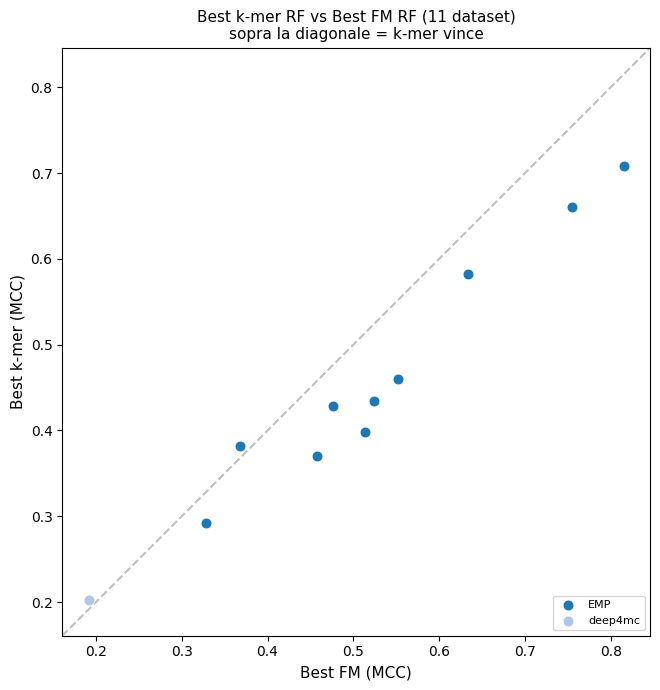

K-mer vince: 2/11, FM vince: 9/11


In [10]:
# Per ogni dataset, best k-mer MCC vs best FM MCC
kmer_mcc_cols = [f'kmer_k{k}_MCC' for k in [4,5,6,7,8]]
fm_mcc_cols = ['fm_NTv3_650M_pre_MCC', 'fm_hyenadna-medium-160k-seqlen-hf_MCC']

best_kmer = df[kmer_mcc_cols].max(axis=1)
best_fm = df[fm_mcc_cols].max(axis=1)

both = pd.DataFrame({'best_kmer': best_kmer, 'best_fm': best_fm,
                      'group': df['group'], 'short': df['short']}).dropna()

fig, ax = plt.subplots(figsize=(7, 7))
for g in both['group'].unique():
    mask = both['group'] == g
    ax.scatter(both.loc[mask, 'best_fm'], both.loc[mask, 'best_kmer'],
               c=[GROUP_COLORS[g]], label=g, s=60, edgecolors='white', linewidth=0.5, zorder=3)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='gray', alpha=0.5, zorder=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Best FM (MCC)', fontsize=11)
ax.set_ylabel('Best k-mer (MCC)', fontsize=11)
ax.set_title(f'Best k-mer RF vs Best FM RF ({len(both)} dataset)\nsopra la diagonale = k-mer vince', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

wins_kmer = (both['best_kmer'] > both['best_fm']).sum()
wins_fm = (both['best_fm'] > both['best_kmer']).sum()
print(f'K-mer vince: {wins_kmer}/{len(both)}, FM vince: {wins_fm}/{len(both)}')

## 5. Ridge R²: quanto bene i k-mer approssimano gli embeddings FM?

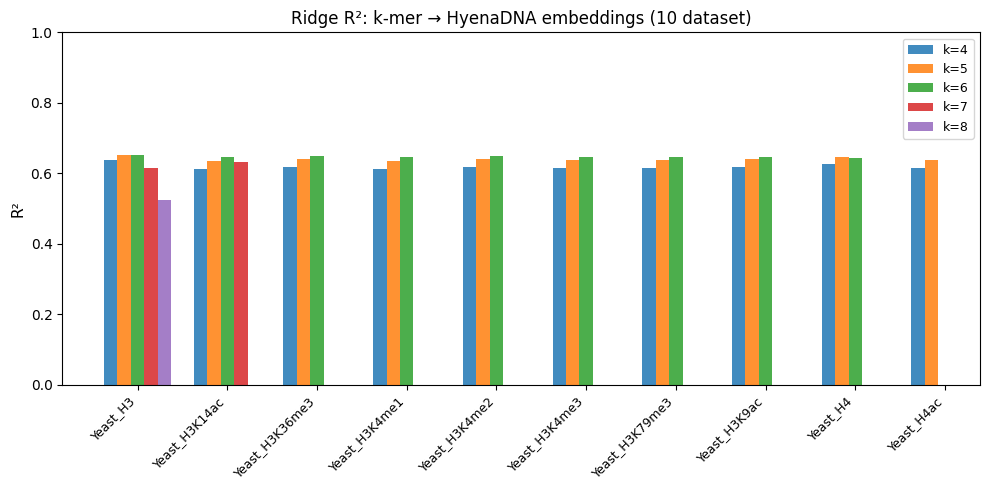

In [6]:
# Bar chart: R2 per dataset e k, raggruppato
k_values = [4, 5, 6, 7, 8]
model_tag = 'hyenadna-medium-160k-seqlen-hf'
r2_cols = [f'ridge_k{k}_{model_tag}_R2' for k in k_values]

r2_data = df[r2_cols + ['short']].dropna(subset=[r2_cols[0]])  # almeno k4

if len(r2_data) == 0:
    print('Nessun dato Ridge R\u00b2 disponibile.')
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(r2_data))
    width = 0.15
    
    for i, k in enumerate(k_values):
        col = f'ridge_k{k}_{model_tag}_R2'
        vals = r2_data[col].values
        mask = ~pd.isna(vals)
        bars = ax.bar(x[mask] + i*width, vals[mask].astype(float), width,
                      label=f'k={k}', alpha=0.85)
    
    ax.set_xticks(x + width*2)
    ax.set_xticklabels(r2_data['short'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('R\u00b2', fontsize=11)
    ax.set_title(f'Ridge R\u00b2: k-mer \u2192 HyenaDNA embeddings ({len(r2_data)} dataset)', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [11]:
# Bar chart: R2 per dataset e k, raggruppato
k_values = [4, 5, 6, 7, 8]
model_tag = 'fm_NTv3_650M_pre_MCC'
r2_cols = [f'ridge_k{k}_{model_tag}_R2' for k in k_values]

r2_data = df[r2_cols + ['short']].dropna(subset=[r2_cols[0]])  # almeno k4

if len(r2_data) == 0:
    print('Nessun dato Ridge R\u00b2 disponibile.')
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(r2_data))
    width = 0.15
    
    for i, k in enumerate(k_values):
        col = f'ridge_k{k}_{model_tag}_R2'
        vals = r2_data[col].values
        mask = ~pd.isna(vals)
        bars = ax.bar(x[mask] + i*width, vals[mask].astype(float), width,
                      label=f'k={k}', alpha=0.85)
    
    ax.set_xticks(x + width*2)
    ax.set_xticklabels(r2_data['short'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('R\u00b2', fontsize=11)
    ax.set_title(f'Ridge R\u00b2: k-mer \u2192 HyenaDNA embeddings ({len(r2_data)} dataset)', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

KeyError: "['ridge_k4_fm_NTv3_650M_pre_MCC_R2', 'ridge_k5_fm_NTv3_650M_pre_MCC_R2', 'ridge_k6_fm_NTv3_650M_pre_MCC_R2', 'ridge_k7_fm_NTv3_650M_pre_MCC_R2', 'ridge_k8_fm_NTv3_650M_pre_MCC_R2'] not in index"

## 6. Ranking per gruppo: MCC medio per metodo

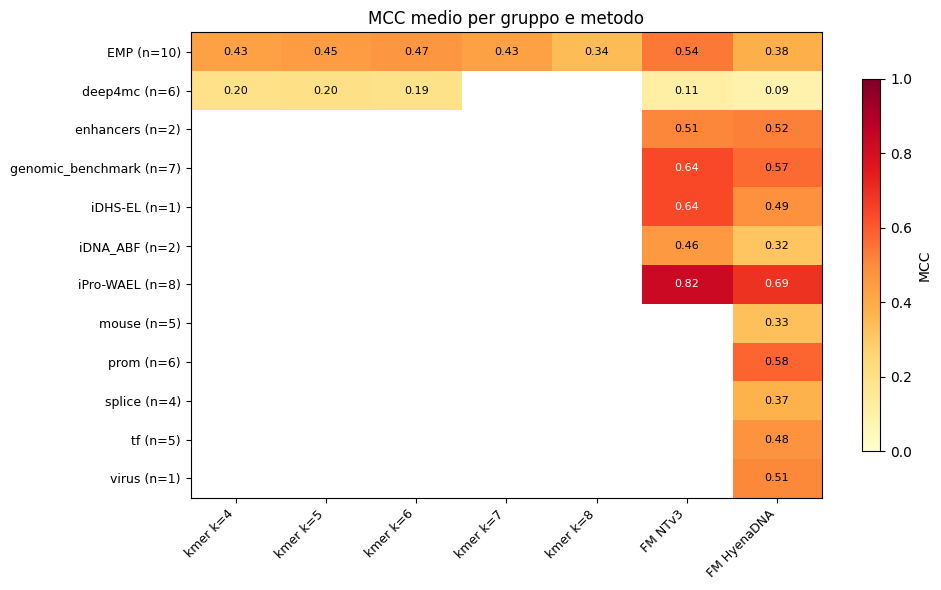

In [7]:
# Heatmap: MCC medio per (gruppo dataset, metodo)
methods = {}
for k in [4,5,6,7,8]:
    col = f'kmer_k{k}_MCC'
    if col in df.columns:
        methods[f'kmer k={k}'] = col
methods['FM NTv3'] = 'fm_NTv3_650M_pre_MCC'
methods['FM HyenaDNA'] = 'fm_hyenadna-medium-160k-seqlen-hf_MCC'

# Media per gruppo
rows = []
for g in sorted(df['group'].unique()):
    gdf = df[df['group'] == g]
    row = {'group': g, 'n': len(gdf)}
    for mname, col in methods.items():
        if col in gdf.columns:
            row[mname] = gdf[col].mean()  # NaN-safe
    rows.append(row)

summary = pd.DataFrame(rows).set_index('group')
n_col = summary.pop('n')

# Drop colonne tutte NaN
summary = summary.dropna(axis=1, how='all')

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(summary.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(summary.columns)))
ax.set_xticklabels(summary.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(summary)))
ax.set_yticklabels([f'{g} (n={int(n_col[g])})' for g in summary.index], fontsize=9)

# Annota valori
for i in range(len(summary)):
    for j in range(len(summary.columns)):
        val = summary.iloc[i, j]
        if pd.notna(val):
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_title('MCC medio per gruppo e metodo', fontsize=12)
plt.colorbar(im, ax=ax, label='MCC', shrink=0.8)
plt.tight_layout()
plt.show()

## 7. Distribuzione MCC per metodo (tutti i dataset)

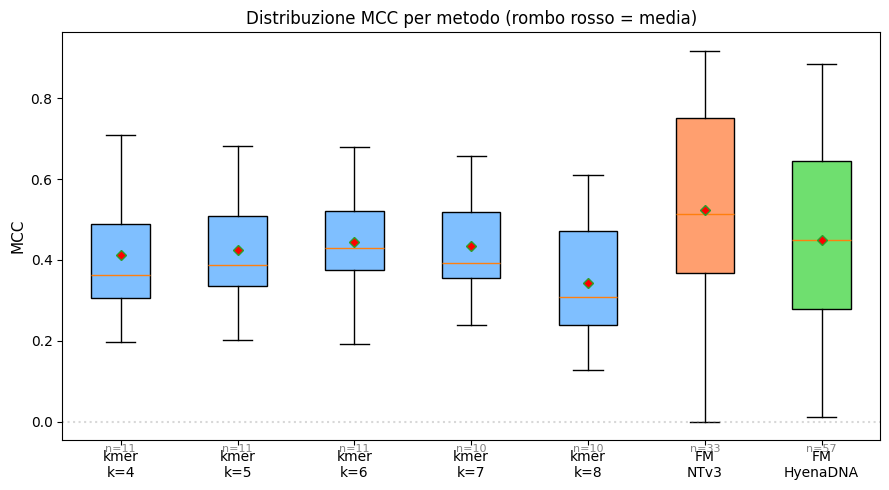

In [8]:
# Boxplot: distribuzione MCC per ogni metodo
method_data = {}
for k in [4,5,6,7,8]:
    col = f'kmer_k{k}_MCC'
    if col in df.columns:
        vals = df[col].dropna()
        if len(vals) > 0:
            method_data[f'kmer\nk={k}'] = vals

for name, col in [('FM\nNTv3', 'fm_NTv3_650M_pre_MCC'),
                   ('FM\nHyenaDNA', 'fm_hyenadna-medium-160k-seqlen-hf_MCC')]:
    if col in df.columns:
        vals = df[col].dropna()
        if len(vals) > 0:
            method_data[name] = vals

fig, ax = plt.subplots(figsize=(9, 5))
positions = range(len(method_data))
bp = ax.boxplot(method_data.values(), positions=positions, widths=0.5,
                patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=5))

colors = ['#7fbfff'] * (len(method_data) - 2) + ['#ff9f6f', '#6fdf6f']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticks(positions)
ax.set_xticklabels(method_data.keys(), fontsize=10)

# Annota n sotto ogni box
for i, (name, vals) in enumerate(method_data.items()):
    ax.text(i, ax.get_ylim()[0] - 0.03, f'n={len(vals)}', ha='center', fontsize=8, color='gray')

ax.set_ylabel('MCC', fontsize=11)
ax.set_title('Distribuzione MCC per metodo (rombo rosso = media)', fontsize=12)
ax.axhline(0, color='gray', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()